#Lab Tasks 06

##Lab Task 1: Build and Train LVQ in Python

The purpose of this task is to download a dataset from Kaggle or the UCI Machine
Learning repository and train an LVQ on it.

**Dataset: Seeds (UCI).** 210 measurements of wheat kernels — 7 continuous
geometric features — belonging to three varieties (Kama, Rosa and Canadian),
**70 of each**. It suits LVQ well: the classes are perfectly balanced, every
feature is numeric with no missing values, and there are three of them, so it
exercises the multi-class behaviour that the manual's two-prototype example
cannot show. A copy is saved next to this notebook as `seeds_dataset.csv`.

*(The task text says "train SOMs algorithm on the dataset" — that sentence is
carried over from the previous lab. The task title and the whole of this lab are
LVQ, so LVQ is what is implemented here.)*

###1. Loading the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler

# One colour per wheat variety, plus the ink tokens used by every chart
CLASS_COLORS = ["#2a78d6", "#eb6834", "#1baf7a"]   # blue, orange, aqua
CLASS_MARKERS = ["o", "^", "s"]
INK, INK_SOFT, GRID = "#0b0b0b", "#52514e", "#e6e5e0"

seeds = pd.read_csv("seeds_dataset.csv")
feature_names = [c for c in seeds.columns if c != "variety"]
class_names = ["Kama", "Rosa", "Canadian"]

print("Shape:", seeds.shape)
print("Missing values:", int(seeds.isna().sum().sum()))
print("\nSamples per variety:")
print(seeds["variety"].value_counts().sort_index().to_string())
print("\nFeature summary:")
print(seeds[feature_names].describe().round(2).to_string())

seeds.head()

Shape: (210, 8)
Missing values: 0

Samples per variety:
variety
1    70
2    70
3    70

Feature summary:
         area  perimeter  compactness  kernel_length  kernel_width  asymmetry  groove_length
count  210.00     210.00       210.00         210.00        210.00     210.00         210.00
mean    14.85      14.56         0.87           5.63          3.26       3.70           5.41
std      2.91       1.31         0.02           0.44          0.38       1.50           0.49
min     10.59      12.41         0.81           4.90          2.63       0.77           4.52
25%     12.27      13.45         0.86           5.26          2.94       2.56           5.04
50%     14.36      14.32         0.87           5.52          3.24       3.60           5.22
75%     17.30      15.72         0.89           5.98          3.56       4.77           5.88
max     21.18      17.25         0.92           6.68          4.03       8.46           6.55


,area,perimeter,compactness,kernel_length,kernel_width,asymmetry,groove_length,variety
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


###2. Data Preprocessing

**Labels to 0-based integers.** The file labels the varieties 1, 2, 3; subtracting
1 gives 0, 1, 2 so the labels can index arrays directly.

**Splitting first.** 70% train / 30% test, stratified so both parts keep 70 / 70 / 70
in proportion. The split is done before scaling so nothing about the test rows
reaches the model.

**Standardising.** This matters more for LVQ than for most models, because LVQ
decides *everything* by Euclidean distance. `area` spans about 10.6 to 21.2
while `compactness` spans 0.81 to 0.92 — roughly a hundredfold difference in
range. Left unscaled, `area` would effectively be the only feature the distance
saw, and `compactness` would be invisible. `StandardScaler` gives every feature
mean 0 and standard deviation 1, fitted **on the training rows only**.

In [2]:
X = seeds[feature_names].to_numpy(dtype="float64")
y = seeds["variety"].to_numpy(dtype=int) - 1     # 1,2,3 -> 0,1,2

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train:", X_train_s.shape, "| per class:", np.bincount(y_train))
print("Test :", X_test_s.shape, "| per class:", np.bincount(y_test))

print("\nFeature ranges before scaling (training set):")
for i, name in enumerate(feature_names):
    print(f"  {name:<15}: {X_train[:, i].min():7.2f} to {X_train[:, i].max():7.2f}")
print("\nAfter scaling every feature has mean 0 and standard deviation 1:")
print("  means:", np.round(X_train_s.mean(axis=0), 3))
print("  stds :", np.round(X_train_s.std(axis=0), 3))

Train: (147, 7) | per class: [49 49 49]
Test : (63, 7) | per class: [21 21 21]

Feature ranges before scaling (training set):
  area           :   10.59 to   21.18
  perimeter      :   12.41 to   17.23
  compactness    :    0.81 to    0.92
  kernel_length  :    4.90 to    6.67
  kernel_width   :    2.63 to    4.03
  asymmetry      :    0.77 to    8.46
  groove_length  :    4.61 to    6.55

After scaling every feature has mean 0 and standard deviation 1:
  means: [-0.  0. -0. -0. -0. -0. -0.]
  stds : [1. 1. 1. 1. 1. 1. 1.]


###3. The LVQ Implementation

This is written from scratch rather than extending the activity's class, which
is hard-wired to exactly two prototypes. This version takes any number of
classes and any number of prototypes per class.

The algorithm is unchanged from the manual:

1. **Initialise** — pick `k` random training samples from each class as that
   class's prototypes.
2. For each training example, find the **winner**: the nearest prototype.
3. **Reward or punish** — if the winner's label matches the example, move it
   towards the example; if not, push it away.
4. Repeat for a number of epochs, **decaying the learning rate** so late updates
   are small.

Two details worth noting. The learning rate decays linearly to zero, so the
prototypes settle instead of oscillating forever. And only the **winner** moves —
unlike the SOM of Lab 04, where the winner's neighbours move as well.

In [3]:
class LVQ:
    """Learning Vector Quantization (LVQ1) for any number of classes."""

    def __init__(self, prototypes_per_class=1, learning_rate=0.1,
                 epochs=50, random_state=None):
        self.prototypes_per_class = prototypes_per_class
        self.initial_learning_rate = learning_rate
        self.epochs = epochs
        self.random_state = random_state
        self.history_ = []

    def _init_prototypes(self, X, y):
        """Start each class's prototypes at random samples of that class."""
        rng = np.random.default_rng(self.random_state)
        vectors, labels = [], []
        for cls in np.unique(y):
            members = X[y == cls]
            chosen = rng.choice(len(members), size=self.prototypes_per_class,
                                replace=False)
            vectors.append(members[chosen])
            labels.extend([cls] * self.prototypes_per_class)
        self.W = np.vstack(vectors).astype(float)
        self.W_labels = np.array(labels)

    def _winner(self, x):
        """Competition: the index of the nearest prototype."""
        return int(np.argmin(np.linalg.norm(self.W - x, axis=1)))

    def fit(self, X, y):
        self._init_prototypes(X, y)
        rng = np.random.default_rng(self.random_state)
        self.history_ = []

        for epoch in range(self.epochs):
            # Linear decay: the last epoch barely moves anything
            alpha = self.initial_learning_rate * (1 - epoch / self.epochs)

            for i in rng.permutation(len(X)):
                x = X[i]
                j = self._winner(x)

                if self.W_labels[j] == y[i]:
                    self.W[j] += alpha * (x - self.W[j])   # reward
                else:
                    self.W[j] -= alpha * (x - self.W[j])   # punish

            self.history_.append((self.predict(X) == y).mean())

        return self

    def predict(self, X):
        """Label each sample with the class of its nearest prototype."""
        distances = np.linalg.norm(X[:, None, :] - self.W[None, :, :], axis=2)
        return self.W_labels[np.argmin(distances, axis=1)]


print("LVQ class defined.")

LVQ class defined.


###4. Choosing the Number of Prototypes

`prototypes_per_class` is the one structural choice LVQ offers, so it is picked
by **5-fold cross-validation on the training set**, repeated with three seeds.

The test set is deliberately not used for this. Trying each value on the test
set and keeping the winner would make the final accuracy an optimistic number
rather than an estimate of how the model handles new data.

In [4]:
def cross_validate(k, X, y, seeds=(0, 1, 2)):
    """Mean 5-fold CV accuracy for k prototypes per class."""
    scores = []
    for seed in seeds:
        folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        fold_scores = []
        for train_idx, val_idx in folds.split(X, y):
            model = LVQ(prototypes_per_class=k, learning_rate=0.1,
                        epochs=50, random_state=seed).fit(X[train_idx], y[train_idx])
            fold_scores.append((model.predict(X[val_idx]) == y[val_idx]).mean())
        scores.append(np.mean(fold_scores))
    return np.mean(scores), np.std(scores)


cv_records = []
for k in (1, 2, 3, 4, 5):
    mean_acc, std_acc = cross_validate(k, X_train_s, y_train)
    cv_records.append({"prototypes_per_class": k, "total_prototypes": k * 3,
                       "cv_accuracy": mean_acc, "cv_std": std_acc})
    print("k=%d (%2d prototypes): CV accuracy %.4f +- %.4f" % (k, k * 3, mean_acc, std_acc))

cv_results = pd.DataFrame(cv_records)
best_k = int(cv_results.loc[cv_results["cv_accuracy"].idxmax(), "prototypes_per_class"])
print("\nBest by cross-validation: k = %d" % best_k)

k=1 ( 3 prototypes): CV accuracy 0.9298 +- 0.0030


k=2 ( 6 prototypes): CV accuracy 0.9251 +- 0.0003


k=3 ( 9 prototypes): CV accuracy 0.9182 +- 0.0053


k=4 (12 prototypes): CV accuracy 0.9070 +- 0.0171


k=5 (15 prototypes): CV accuracy 0.9092 +- 0.0060

Best by cross-validation: k = 1


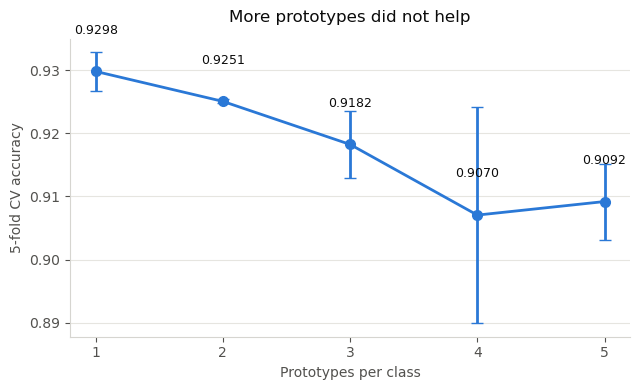

In [5]:
figure, axes = plt.subplots(figsize=(6.5, 4))

axes.errorbar(cv_results["prototypes_per_class"], cv_results["cv_accuracy"],
              yerr=cv_results["cv_std"], color=CLASS_COLORS[0], linewidth=2,
              marker="o", markersize=7, capsize=4)

for _, row in cv_results.iterrows():
    axes.text(row["prototypes_per_class"], row["cv_accuracy"] + 0.006,
              f"{row['cv_accuracy']:.4f}", ha="center", fontsize=9, color=INK)

axes.set_xlabel("Prototypes per class", color=INK_SOFT)
axes.set_ylabel("5-fold CV accuracy", color=INK_SOFT)
axes.set_title("More prototypes did not help", color=INK, fontsize=12, pad=12)
axes.set_xticks(cv_results["prototypes_per_class"])

axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
axes.spines["left"].set_color("#d6d5d0")
axes.spines["bottom"].set_color("#d6d5d0")
axes.tick_params(colors=INK_SOFT)
axes.yaxis.grid(True, color=GRID, linewidth=0.8)
axes.set_axisbelow(True)

plt.tight_layout()
plt.show()

###5. Training the Final Model

The chosen number of prototypes, trained on the whole training set.

In [6]:
model = LVQ(prototypes_per_class=best_k, learning_rate=0.1,
            epochs=50, random_state=42).fit(X_train_s, y_train)

print("Prototypes: %d (%d per class x 3 classes)" % (len(model.W), best_k))
print("Training accuracy: %.4f" % (model.predict(X_train_s) == y_train).mean())
print("\nLearned prototypes (standardised units):")
print(pd.DataFrame(np.round(model.W, 3), columns=feature_names,
                   index=[f"{class_names[c]} ({c})" for c in model.W_labels]).to_string())

Prototypes: 3 (1 per class x 3 classes)
Training accuracy: 0.9456

Learned prototypes (standardised units):
               area  perimeter  compactness  kernel_length  kernel_width  asymmetry  groove_length
Kama (0)     -0.103     -0.125        0.441         -0.178         0.040     -0.803         -0.640
Rosa (1)      1.268      1.276        0.548          1.261         1.161     -0.012          1.324
Canadian (2) -1.096     -1.066       -1.107         -0.933        -1.175      0.870         -0.614


###6. The Learning Curve

Training accuracy after each pass over the data. This curve does **not** have
the usual shape of one, and the reason is worth spelling out.

There is no climb from a low starting point, because there is nothing to climb
from: the prototypes are initialised **at actual training samples of their own
class**, so before a single update the model is already a reasonable classifier.
Accuracy is at its highest value on the very first epoch.

What the rest of the curve shows is the prototypes being nudged back and forth
inside a narrow band, a few samples wide, as the reward and punish steps pull
against each other. As the learning rate decays those steps shrink and the
movement settles.

The honest reading is that on this dataset LVQ training changes very little —
which is the same conclusion the next section reaches from a different
direction.

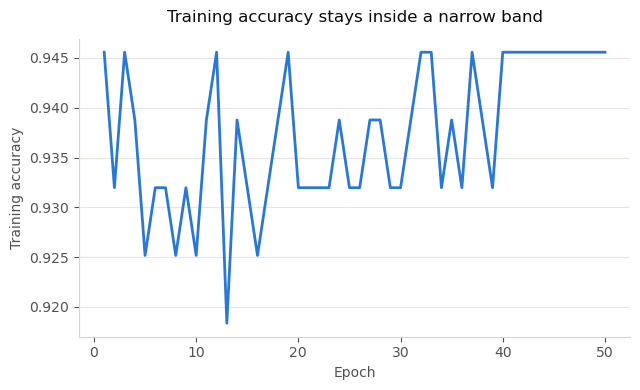

Training accuracy over 50 epochs
  first epoch: 0.9456
  best       : 0.9456
  worst      : 0.9184
  final      : 0.9456
  the whole curve spans 0.9184 - 0.9456, a band of 4.0 samples out of 147
  distinct values taken: [np.float64(0.9184), np.float64(0.9252), np.float64(0.932), np.float64(0.9388), np.float64(0.9456)]


In [7]:
figure, axes = plt.subplots(figsize=(6.5, 4))

epochs_ran = np.arange(1, len(model.history_) + 1)
axes.plot(epochs_ran, model.history_, color=CLASS_COLORS[0], linewidth=2)

axes.set_xlabel("Epoch", color=INK_SOFT)
axes.set_ylabel("Training accuracy", color=INK_SOFT)
axes.set_title("Training accuracy stays inside a narrow band",
               color=INK, fontsize=12, pad=12)

axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
axes.spines["left"].set_color("#d6d5d0")
axes.spines["bottom"].set_color("#d6d5d0")
axes.tick_params(colors=INK_SOFT)
axes.yaxis.grid(True, color=GRID, linewidth=0.8)
axes.set_axisbelow(True)

plt.tight_layout()
plt.show()

history = np.array(model.history_)
print("Training accuracy over %d epochs" % len(history))
print("  first epoch: %.4f" % history[0])
print("  best       : %.4f" % history.max())
print("  worst      : %.4f" % history.min())
print("  final      : %.4f" % history[-1])
print("  the whole curve spans %.4f - %.4f, a band of %.1f samples out of %d" % (
    history.min(), history.max(),
    (history.max() - history.min()) * len(X_train_s), len(X_train_s)))
print("  distinct values taken:", sorted(np.unique(np.round(history, 4))))

###7. Where the Prototypes Ended Up

The data has 7 features, so it cannot be drawn directly. Projecting onto its
first two principal components keeps most of the variance and gives a fair
picture of the layout. The prototypes are projected with the **same** transform,
so their positions are comparable to the data points.

Each variety has its own colour *and* its own marker shape, so the three groups
stay distinguishable without relying on colour alone.

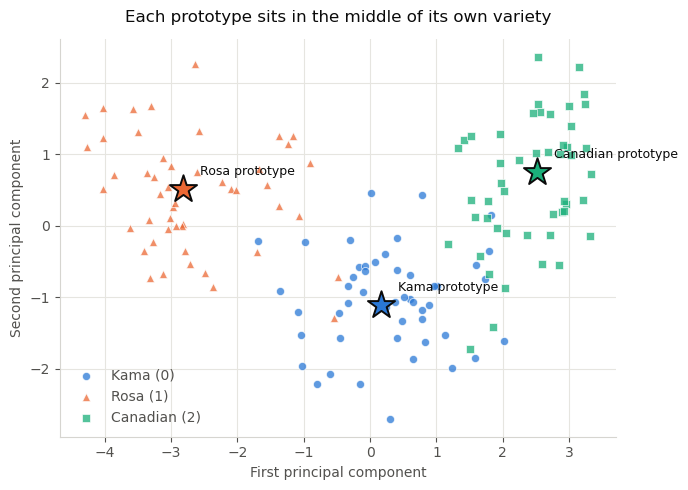

The two components shown cover 89.2% of the variance.


In [8]:
# PCA by hand: centre the data, take the top two eigenvectors of the covariance
mean_vector = X_train_s.mean(axis=0)
centred = X_train_s - mean_vector
covariance = np.cov(centred, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eigh(covariance)
order = np.argsort(eigenvalues)[::-1][:2]
components = eigenvectors[:, order]
explained = eigenvalues[order].sum() / eigenvalues.sum()

train_2d = centred @ components
prototypes_2d = (model.W - mean_vector) @ components

figure, axes = plt.subplots(figsize=(7, 5))

for cls in range(3):
    points = train_2d[y_train == cls]
    axes.scatter(points[:, 0], points[:, 1], s=34, alpha=0.75,
                 color=CLASS_COLORS[cls], marker=CLASS_MARKERS[cls],
                 edgecolor="white", linewidth=0.6,
                 label=f"{class_names[cls]} ({cls})")

for position, cls in zip(prototypes_2d, model.W_labels):
    axes.scatter(position[0], position[1], s=420, marker="*",
                 color=CLASS_COLORS[cls], edgecolor=INK, linewidth=1.4, zorder=5)
    axes.annotate(f"{class_names[cls]} prototype",
                  (position[0], position[1]), textcoords="offset points",
                  xytext=(12, 10), fontsize=9, color=INK)

axes.set_xlabel(f"First principal component", color=INK_SOFT)
axes.set_ylabel("Second principal component", color=INK_SOFT)
axes.set_title("Each prototype sits in the middle of its own variety",
               color=INK, fontsize=12, pad=12)
axes.legend(frameon=False, labelcolor=INK_SOFT, loc="best")

axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
axes.spines["left"].set_color("#d6d5d0")
axes.spines["bottom"].set_color("#d6d5d0")
axes.tick_params(colors=INK_SOFT)
axes.grid(True, color=GRID, linewidth=0.8)
axes.set_axisbelow(True)

plt.tight_layout()
plt.show()

print("The two components shown cover %.1f%% of the variance." % (explained * 100))

###8. How Close Are the Prototypes to the Class Averages?

The picture suggests each prototype sits near the centre of its variety. That is
worth measuring rather than eyeballing, because if a prototype simply ends up at
the class mean then the training has not added anything a simple average would
not have given.

In [9]:
centroids = np.vstack([X_train_s[y_train == cls].mean(axis=0) for cls in range(3)])

print("Distance from each prototype to its class centroid,")
print("against how far a typical member of that class sits from the same centroid:\n")
for cls in range(3):
    prototype = model.W[model.W_labels == cls][0]
    to_centroid = np.linalg.norm(prototype - centroids[cls])
    spread = np.linalg.norm(X_train_s[y_train == cls] - centroids[cls], axis=1).mean()
    print(f"  {class_names[cls]:<9}: prototype is {to_centroid:.3f} from the centroid, "
          f"a typical member is {spread:.3f}  ({spread / to_centroid:.1f}x further)")

Distance from each prototype to its class centroid,
against how far a typical member of that class sits from the same centroid:

  Kama     : prototype is 0.153 from the centroid, a typical member is 1.260  (8.2x further)
  Rosa     : prototype is 0.147 from the centroid, a typical member is 1.344  (9.1x further)
  Canadian : prototype is 0.197 from the centroid, a typical member is 1.346  (6.8x further)


###9. Evaluation on the Test Set

The held-out 30% of the data, which took no part in training, in the
cross-validation, or in fitting the scaler.

In [10]:
predictions = model.predict(X_test_s)
accuracy = (predictions == y_test).mean()

print("Test accuracy: %.4f  (%d of %d correct)" % (
    accuracy, int((predictions == y_test).sum()), len(y_test)))

confusion = pd.crosstab(
    pd.Series([class_names[c] for c in y_test], name="actual"),
    pd.Series([class_names[c] for c in predictions], name="predicted"))
print("\nConfusion matrix:")
print(confusion.to_string())

print("\nPer class:")
for cls in range(3):
    true_positive = int(((predictions == cls) & (y_test == cls)).sum())
    predicted_positive = int((predictions == cls).sum())
    actual_positive = int((y_test == cls).sum())
    precision = true_positive / predicted_positive if predicted_positive else 0.0
    recall = true_positive / actual_positive if actual_positive else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    print(f"  {class_names[cls]:<9}: precision {precision:.4f} | "
          f"recall {recall:.4f} | f1 {f1:.4f}")

Test accuracy: 0.8571  (54 of 63 correct)

Confusion matrix:
predicted  Canadian  Kama  Rosa
actual                         
Canadian         20     1     0
Kama              4    16     1
Rosa              0     3    18

Per class:
  Kama     : precision 0.8000 | recall 0.7619 | f1 0.7805
  Rosa     : precision 0.9474 | recall 0.8571 | f1 0.9000
  Canadian : precision 0.8333 | recall 0.9524 | f1 0.8889


###10. Does the Seed Matter?

The prototypes start at randomly chosen training samples, so a different seed
gives a different starting point. Training is repeated with five seeds to see
how much of the accuracy above is the method and how much is luck.

In [11]:
seed_scores = []
for seed in range(5):
    m = LVQ(prototypes_per_class=best_k, learning_rate=0.1,
            epochs=50, random_state=seed).fit(X_train_s, y_train)
    seed_scores.append((m.predict(X_test_s) == y_test).mean())
seed_scores = np.array(seed_scores)

print("Test accuracy per seed:", np.round(seed_scores, 4))
print("  mean %.4f | std %.4f" % (seed_scores.mean(), seed_scores.std()))

Test accuracy per seed: [0.873  0.8571 0.8571 0.8571 0.873 ]
  mean 0.8635 | std 0.0078


###11. Comparison with Two Baselines

LVQ's claim is that a handful of learned prototypes can stand in for the whole
training set. Two reference points make that claim testable:

* **Nearest centroid** — one prototype per class, placed at the class average,
  with **no learning at all**. If LVQ cannot beat this, its training has
  achieved nothing.
* **1-nearest-neighbour** — keep every training point and classify by the
  closest one. This is the accuracy LVQ is trying to approach while storing far
  less.

In [12]:
# Nearest centroid
distances = np.linalg.norm(X_test_s[:, None, :] - centroids[None, :, :], axis=2)
centroid_accuracy = (np.argmin(distances, axis=1) == y_test).mean()

# 1-nearest-neighbour against the full training set
distances = np.linalg.norm(X_test_s[:, None, :] - X_train_s[None, :, :], axis=2)
knn_accuracy = (y_train[np.argmin(distances, axis=1)] == y_test).mean()

comparison = pd.DataFrame([
    {"method": "Nearest centroid (no learning)", "stored": 3, "test_accuracy": centroid_accuracy},
    {"method": f"LVQ ({len(model.W)} prototypes)", "stored": len(model.W), "test_accuracy": seed_scores.mean()},
    {"method": "1-nearest-neighbour", "stored": len(X_train_s), "test_accuracy": knn_accuracy},
])
print(comparison.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\nLVQ stores %d points instead of %d - a %.0fx reduction." % (
    len(model.W), len(X_train_s), len(X_train_s) / len(model.W)))

                        method  stored  test_accuracy
Nearest centroid (no learning)       3         0.8571
            LVQ (3 prototypes)       3         0.8635
           1-nearest-neighbour     147         0.9048

LVQ stores 3 points instead of 147 - a 49x reduction.


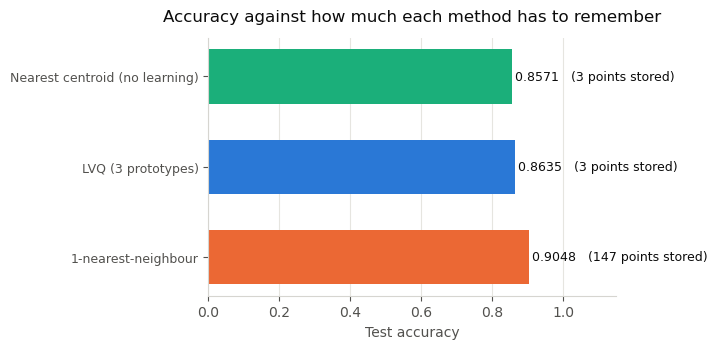

In [13]:
figure, axes = plt.subplots(figsize=(7, 3.6))

positions = np.arange(len(comparison))
bars = axes.barh(positions, comparison["test_accuracy"], height=0.6,
                 color=[CLASS_COLORS[2], CLASS_COLORS[0], CLASS_COLORS[1]])

for bar, (_, row) in zip(bars, comparison.iterrows()):
    axes.text(row["test_accuracy"] + 0.008, bar.get_y() + bar.get_height() / 2,
              f"{row['test_accuracy']:.4f}   ({row['stored']} points stored)",
              va="center", fontsize=9, color=INK)

axes.set_yticks(positions)
axes.set_yticklabels(comparison["method"], fontsize=9)
axes.invert_yaxis()
axes.set_xlim(0, 1.15)
axes.set_xlabel("Test accuracy", color=INK_SOFT)
axes.set_title("Accuracy against how much each method has to remember",
               color=INK, fontsize=12, pad=12)

axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
axes.spines["left"].set_color("#d6d5d0")
axes.spines["bottom"].set_color("#d6d5d0")
axes.tick_params(colors=INK_SOFT)
axes.xaxis.grid(True, color=GRID, linewidth=0.8)
axes.set_axisbelow(True)

plt.tight_layout()
plt.show()

##Report - Lab Task 1

*The manual asks for a short report covering the points below.*

###1. Data preprocessing steps

The Seeds dataset (UCI) holds 210 wheat kernels described by 7 continuous
geometric measurements, in three varieties with exactly 70 examples each. There
were **no missing values** and every feature was already numeric, so no cleaning
was required. Three steps were applied.

**Re-indexed the labels.** The file numbers the varieties 1, 2, 3. Subtracting 1
gives 0, 1, 2, so a label can be used directly as an array index.

**Split before scaling.** 70% train (147 rows) and 30% test (63 rows),
stratified so both keep the 1:1:1 class balance. The split came first so that
nothing about the test rows could reach the scaler or the model.

**Standardised every feature.** This matters more for LVQ than for most models,
because LVQ decides *everything* — which prototype wins, and therefore which
prototype moves — by Euclidean distance. In raw units `area` spans about 10.6 to
21.2 while `compactness` spans 0.81 to 0.92. Distance would have been almost
entirely a measure of `area`, and `compactness` would have been invisible.
`StandardScaler`, fitted on the training rows only, puts every feature on mean 0
and standard deviation 1.

###2. Model architecture and rationale for the chosen hyperparameters

LVQ has two layers: 7 input nodes, one per feature, and one output node per
prototype. Each prototype is a point in the same 7-dimensional space as the
data and carries a fixed class label.

| Choice | Value | Rationale |
|---|---|---|
| Prototypes per class | **1** (3 in total) | Chosen by 5-fold cross-validation on the training set, repeated over three seeds. Accuracy fell steadily as prototypes were added — 0.9298 at k=1 down to 0.9070 at k=4 — so the simplest model won on merit rather than by assumption. |
| Initialisation | a random training sample of each class | The manual's approach. It guarantees each prototype starts inside its own class rather than somewhere arbitrary. |
| Learning rate | 0.1, decaying linearly to 0 | Large enough to move prototypes meaningfully at the start; the decay makes late updates small so the prototypes settle instead of oscillating indefinitely. |
| Epochs | 50 | The curve is flat well before this, so more passes would only cost time. |
| Distance | Euclidean | What the manual specifies, and what the standardisation above is designed for. |

The number of prototypes was the only structural choice available, which is why
it was the one cross-validated. Selecting it on the test set instead would have
turned the final accuracy into an optimistic number rather than an estimate of
performance on unseen data.

###3. Training process and evaluation metrics

Training is online: one sample at a time, in a fresh random order each epoch.
For each sample the nearest prototype is found, and then it is either moved
**towards** the sample (if their labels agree) or pushed **away** (if they do
not). Only the winner moves — unlike the SOM in Lab 04, where neighbours move too.

| Metric | Value |
|---|---|
| Cross-validation accuracy (training set, k=1) | 0.9298 |
| Training accuracy | 0.9456 |
| **Test accuracy** (seed 42) | **0.8571** (54 of 63) |
| Test accuracy across 5 seeds | 0.8635 mean, 0.0078 std |
| Nearest-centroid baseline | 0.8571 |
| 1-nearest-neighbour baseline | 0.9048 |

Accuracy is a fair headline here because the three classes are exactly balanced,
so there is no majority class to hide behind. Per-class precision, recall and F1
were computed anyway, since they show *where* the errors fall.

###4. Observations and insights

**The model works, and it is extremely compact.** 0.8635 mean test accuracy from
**three stored points** — one per class — against 147 training rows. That is the
entire claim of LVQ: a handful of prototypes standing in for the whole dataset,
a 49x reduction in what has to be kept.

**But on this dataset the training barely earns its keep.** The nearest-centroid
baseline — three points placed at the class averages, with **no learning at
all** — scores 0.8571 against LVQ's 0.8635. Measuring the prototypes directly
explains why: each one ends up **0.15 to 0.20** away from its class centroid,
while a typical member of that class sits **1.26 to 1.35** away. The prototypes
have converged to within a fraction of the class means, so LVQ has rediscovered
the centroids rather than improving on them.

**Which is what the learning curve was saying too.** Training accuracy is at its
maximum on the first epoch and then moves inside a band a few samples wide. With
one prototype per class, initialised inside its own class, on three roughly
spherical and well-separated clusters, there is very little for the reward and
punish steps to fix.

**The interesting gap is against 1-NN.** Keeping all 147 training points scores
0.9048, about four points better. That gap is the price of the compression, and
it is where LVQ's remaining errors live: the confusion matrix shows Kama is the
hard class, with 4 of its 21 test kernels going to Canadian. Kama sits
**between** the other two varieties in the projection, so a single prototype
cannot describe its boundary — but 1-NN, with every training point available,
can follow it.

**Why more prototypes did not fix that.** The obvious response is to give Kama
more prototypes, and cross-validation says it does not help: accuracy fell
monotonically from k=1 to k=4. With only 49 training samples per class, each
extra prototype is fitted from fewer examples, and the variance added costs more
than the extra flexibility gains. On a larger dataset the trade would likely go
the other way.

**A note on method.** k=2 would in fact have scored higher on this particular
test set than the k=1 that cross-validation chose. That is not a reason to
switch to it: the choice has to be made without looking at the test set, and the
differences involved — under two points on 63 samples, which is roughly one
kernel — are well inside the noise.

#End!